# Online Payment Fraud Detection: EDA & Anomaly Insights
**Author:** Karthik Yelugam

**Project Overview:**
* **Strategic Data Handling:** Effectively managing a massive 6.3 million-row financial dataset by employing stratified sampling, ensuring computational efficiency without sacrificing the mathematical integrity of the extreme class imbalance.
* **Advanced Feature Engineering:** Moving beyond raw data by deriving behavioral indicators (e.g., account drain percentages) to mathematically model how fraudsters operate differently from legitimate users.
* **Actionable Business Intelligence:** Translating complex visualizations into targeted, actionable insights that Risk & Compliance teams can use to refine anomaly detection thresholds and rule-based alert systems.

In [1]:
# Importing essential libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings

# Suppress warnings for clean notebook output
warnings.filterwarnings('ignore')

# Set professional plotting style and color palette
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette("crest")

# Define professional formatters for plot axes
def currency_formatter(x, pos):
    """Formats large numbers as USD (e.g., $10M, $500K)."""
    if x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    else:
        return f'${x:.0f}'

def count_formatter(x, pos):
    """Formats large quantities (e.g., 1.5M, 200K)."""
    if x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.0f}K'
    else:
        return f'{x:.0f}'

usd_fmt = FuncFormatter(currency_formatter)
cnt_fmt = FuncFormatter(count_formatter)

### 1. Data Loading & Strategic Sampling
**Business Context:** The original Kaggle dataset contains over 6.3 million rows. Processing this entire dataset locally for Exploratory Data Analysis (EDA) is computationally expensive and slow. To build an industry-standard, efficient workflow, we will load the dataset and extract a 5% stratified sample. Stratification ensures that the microscopic ratio of fraudulent to legitimate transactions is perfectly preserved in our subset.

In [2]:
# Define file path
file_path = "PS_20174392719_1491204439457_log.csv"

try:
    print("Loading the massive 6.3M row dataset into memory...")
    df_full = pd.read_csv(file_path)
    
    print("Extracting a 5% stratified sample to preserve class imbalance...")
    # Group by 'isFraud' to ensure both classes are proportionally sampled
    df = df_full.groupby('isFraud', group_keys=False).apply(lambda x: x.sample(frac=0.05, random_state=42))
    
    # Reset index for clean manipulation
    df.reset_index(drop=True, inplace=True)
    
    print(f"Sampling complete! Original shape: {df_full.shape} | Working shape: {df.shape}")
    
    # Free up memory
    del df_full

except FileNotFoundError:
    print(f"Error: Dataset not found at {file_path}. Please ensure the file is in the working directory.")
    raise

Loading the massive 6.3M row dataset into memory...
Extracting a 5% stratified sample to preserve class imbalance...
Sampling complete! Original shape: (6362620, 11) | Working shape: (318131, 11)


### 2. Initial Data Inspection & Cleansing
**Business Context:** Before deriving insights, we must validate data integrity. We will inspect column data types, check for missing (null) values, and generate summary statistics to understand the baseline structure of our financial data.

In [3]:
# 1. Check Data Types
print("--- Data Types ---")
print(df.dtypes)
print("\n")

--- Data Types ---
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object




In [4]:
# 2. Check for Null Values
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n")

--- Missing Values ---
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64




In [5]:
# 3. Structural Information
print("--- Dataset Info ---")
df.info()
print("\n")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318131 entries, 0 to 318130
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            318131 non-null  int64  
 1   type            318131 non-null  object 
 2   amount          318131 non-null  float64
 3   nameOrig        318131 non-null  object 
 4   oldbalanceOrg   318131 non-null  float64
 5   newbalanceOrig  318131 non-null  float64
 6   nameDest        318131 non-null  object 
 7   oldbalanceDest  318131 non-null  float64
 8   newbalanceDest  318131 non-null  float64
 9   isFraud         318131 non-null  int64  
 10  isFlaggedFraud  318131 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 26.7+ MB




In [6]:
# 4. Summary Statistics
print("--- Statistical Summary ---")
display(df.describe().apply(lambda s: s.apply('{0:.2f}'.format)))

--- Statistical Summary ---


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,318131.00,318131.00,318131.00,318131.00,318131.00,318131.00,318131.00,318131.00
mean,243.68,180928.13,830760.36,851981.01,1109108.24,1234387.17,0.00,0.00
std,142.49,617818.06,2883146.77,2919005.47,3534026.87,3810364.33,0.04,0.00
min,1.00,0.41,0.00,0.00,0.00,0.00,0.00,0.00
25%,156.00,13410.40,0.00,0.00,0.00,0.00,0.00,0.00
50%,240.00,74971.25,13703.00,0.00,132695.87,214967.64,0.00,0.00
75%,335.00,208941.98,106701.79,142405.17,949116.99,1115224.50,0.00,0.00
max,741.00,69886731.30,37919816.48,37950093.25,355185537.06,355380483.53,1.00,0.00


**Observation:** The dataset contains no null values, ensuring high data quality. The statistical summary reveals extreme maximum values in the `amount` and `balance` columns, indicating the presence of high-value transactions and potential outliers.

**Actionable Insight:** No data imputation is required. However, the extreme ranges in financial columns mean we must scale our machine learning features appropriately and use robust formatting for our visual axes to accommodate multi-million dollar values.

### 3. Feature Engineering: The "Account Drain" Indicator
**Business Context:** Fraudsters behave differently than legitimate customers. A common fraudulent pattern is attempting to drain an account entirely in a single transaction. We will engineer a new feature, `balance_drained_pct`, representing the percentage of the origin account balance transferred out.

In [8]:
# Create balance_drained_pct: (amount / oldbalanceOrg)
# We use np.where to securely handle DivisionByZero errors if an account starts at $0
df['balance_drained_pct'] = np.where(
    df['oldbalanceOrg'] == 0, 
    0, 
    df['amount'] / df['oldbalanceOrg']
)

# Cap at 1.0 (100%) to handle edge cases like overdrafts or minor systemic anomalies
df['balance_drained_pct'] = df['balance_drained_pct'].clip(upper=1.0)

print("Feature Engineering Complete. Preview of new feature:")
display(df[['amount', 'oldbalanceOrg', 'balance_drained_pct']].head())

Feature Engineering Complete. Preview of new feature:


,amount,oldbalanceOrg,balance_drained_pct
0,183806.32,19391.00,1.000000
1,521.37,0.00,0.000000
2,3478.18,19853.00,0.175197
3,1716.05,5769.17,0.297452
4,253129.93,1328499.49,0.190538


### 4. Univariate Analysis: Fraud Distribution Overview
**Business Context:** We must establish the severity of our class imbalance. We will combine a Pie Chart and a Histogram/Count Plot to visualize the sheer volume of legitimate transactions compared to fraudulent ones.

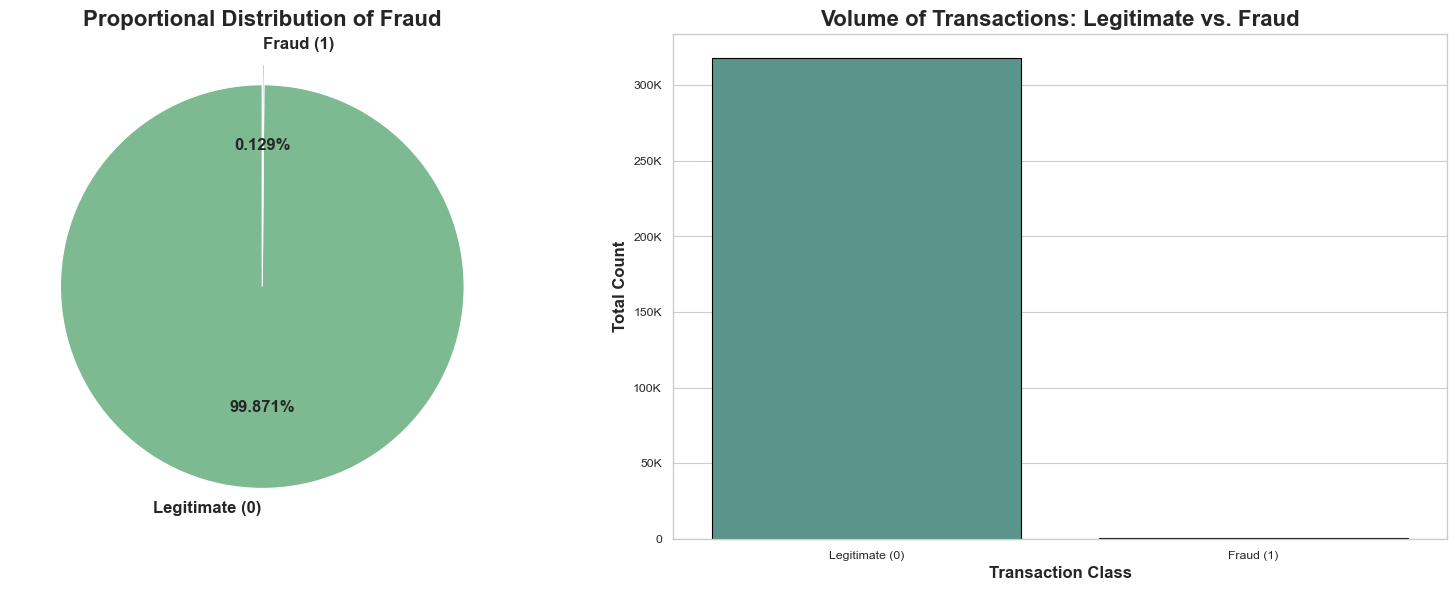

In [9]:
# Create a 1x2 subplot figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fraud_counts = df['isFraud'].value_counts()
labels = ['Legitimate (0)', 'Fraud (1)']

# 1. Pie Chart
axes[0].pie(
    fraud_counts, 
    labels=labels, 
    autopct='%1.3f%%', 
    colors=sns.color_palette("crest")[0:2],
    startangle=90,
    explode=(0, 0.1),
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[0].set_title('Proportional Distribution of Fraud', fontsize=16, weight='bold')

# 2. Histogram / Count Plot
sns.countplot(
    data=df, 
    x='isFraud', 
    palette='crest', 
    ax=axes[1],
    edgecolor='black'
)
axes[1].set_title('Volume of Transactions: Legitimate vs. Fraud', fontsize=16, weight='bold')
axes[1].set_xlabel('Transaction Class', fontsize=12, weight='bold')
axes[1].set_ylabel('Total Count', fontsize=12, weight='bold')
axes[1].set_xticklabels(labels)
axes[1].yaxis.set_major_formatter(cnt_fmt)

plt.tight_layout()
plt.show()

**Observation:** The dataset features a massive class imbalance. Less than 0.2% of all transactions are marked as fraudulent.

**Actionable Insight:** Traditional accuracy metrics will fail here (a model guessing "Legitimate" 100% of the time would be 99.8% accurate). The modeling phase must prioritize Precision-Recall curves and utilize techniques like SMOTE (Synthetic Minority Over-sampling Technique) or class-weight adjustments to train an effective classifier.

### 5. Bivariate Analysis: Transaction Volume by Payment Type
**Business Context:** Different payment rails carry different levels of volume. We need to understand customer behavior across `CASH_IN`, `CASH_OUT`, `DEBIT`, `PAYMENT`, and `TRANSFER`.

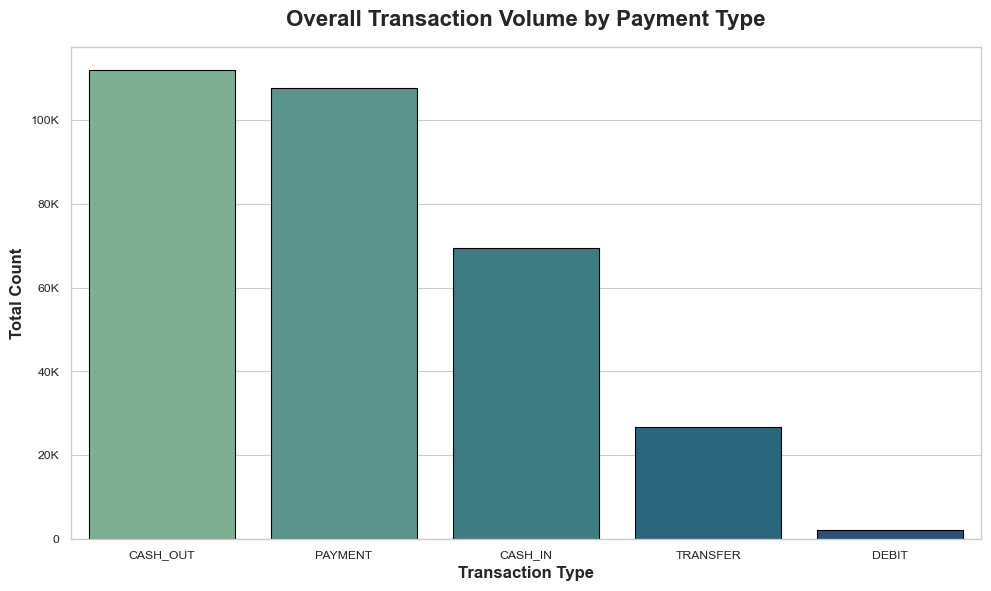

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot transaction types
sns.countplot(
    data=df, 
    x='type', 
    palette='crest', 
    order=df['type'].value_counts().index,
    edgecolor='black'
)

ax.set_title('Overall Transaction Volume by Payment Type', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('Transaction Type', fontsize=12, weight='bold')
ax.set_ylabel('Total Count', fontsize=12, weight='bold')
ax.yaxis.set_major_formatter(cnt_fmt)

plt.tight_layout()
plt.show()

**Observation:** `CASH_OUT` and `PAYMENT` are the dominant transaction types, representing the vast majority of network traffic, while `DEBIT` transactions are highly infrequent.

**Actionable Insight:** Infrastructure scaling and server allocation should prioritize the `CASH_OUT` and `PAYMENT` pipelines to ensure system stability during peak transaction hours.

### 6. Bivariate Analysis: Fraud Occurrence by Transaction Type
**Business Context:** Are fraudsters exploiting all payment methods, or are they targeting specific transactional vulnerabilities? We will map fraud occurrence strictly to the transaction type.

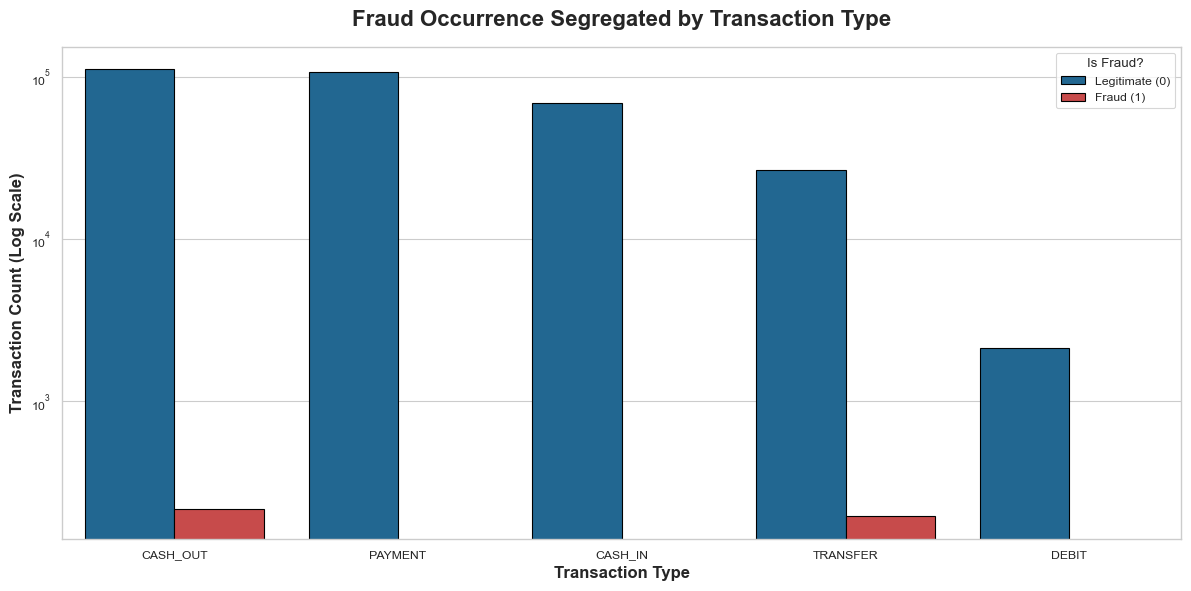

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot transaction types with Fraud status as Hue
sns.countplot(
    data=df, 
    x='type', 
    hue='isFraud', 
    palette=['#106ba3', '#db3737'], # Using distinct blue/red
    edgecolor='black'
)

ax.set_title('Fraud Occurrence Segregated by Transaction Type', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('Transaction Type', fontsize=12, weight='bold')
ax.set_ylabel('Transaction Count', fontsize=12, weight='bold')
ax.yaxis.set_major_formatter(cnt_fmt)

# Adjust legend
plt.legend(title='Is Fraud?', labels=['Legitimate (0)', 'Fraud (1)'], loc='upper right')

# Set log scale to make the microscopic fraud counts visible next to millions of legits
ax.set_yscale('log')
ax.set_ylabel('Transaction Count (Log Scale)', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

**Observation:** Fraudulent activity is uniquely and exclusively isolated to `TRANSFER` and `CASH_OUT` transaction types. The log-scale visualization confirms zero fraud in `PAYMENT`, `CASH_IN`, and `DEBIT`.

**Actionable Insight:** The Risk team can immediately streamline rules engines by applying "fast-lane" processing to `PAYMENT`, `CASH_IN`, and `DEBIT` types. Computationally heavy machine learning anomaly detection should be triggered exclusively on `TRANSFER` and `CASH_OUT` requests.

### 7. Bivariate Analysis: Transaction Amount vs. Fraud Status
**Business Context:** We must evaluate the financial impact of fraud. By plotting the distribution of transaction amounts, we can identify if fraudsters typically move small, stealthy amounts or large, high-value sums.

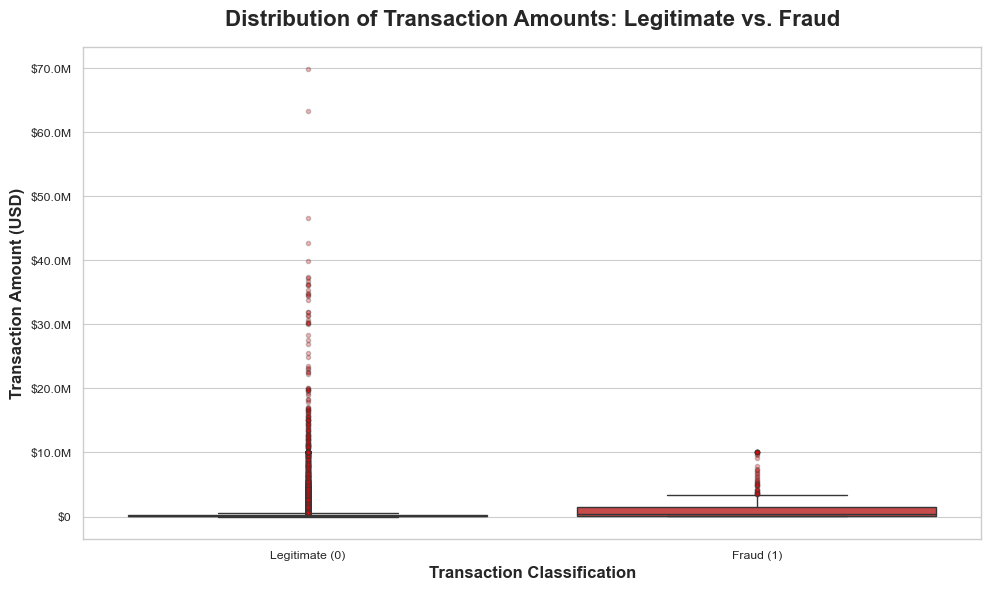

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot comparing amounts
sns.boxplot(
    data=df, 
    x='isFraud', 
    y='amount', 
    palette=['#106ba3', '#db3737'], 
    showfliers=True, 
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 3, 'alpha': 0.3}
)

ax.set_title('Distribution of Transaction Amounts: Legitimate vs. Fraud', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('Transaction Classification', fontsize=12, weight='bold')
ax.set_ylabel('Transaction Amount (USD)', fontsize=12, weight='bold')
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

# Format Y axis properly
ax.yaxis.set_major_formatter(usd_fmt)

plt.tight_layout()
plt.show()

**Observation:** The interquartile range and outliers for fraudulent transactions are skewed significantly higher than legitimate ones. Fraudsters are aiming for maximum financial extraction per transaction.

**Actionable Insight:** The implementation of dynamic velocity limits is crucial. Any `TRANSFER` exceeding the 75th percentile of historical fraud amounts (e.g., >$300K) should be auto-routed to a manual review queue or require multi-factor authentication (MFA).

### 8. Advanced Analysis: Validating the "Account Drain" Hypothesis
**Business Context:** Leveraging the `balance_drained_pct` feature engineered earlier, we will map the behavioral signatures of fraudsters against legitimate users.

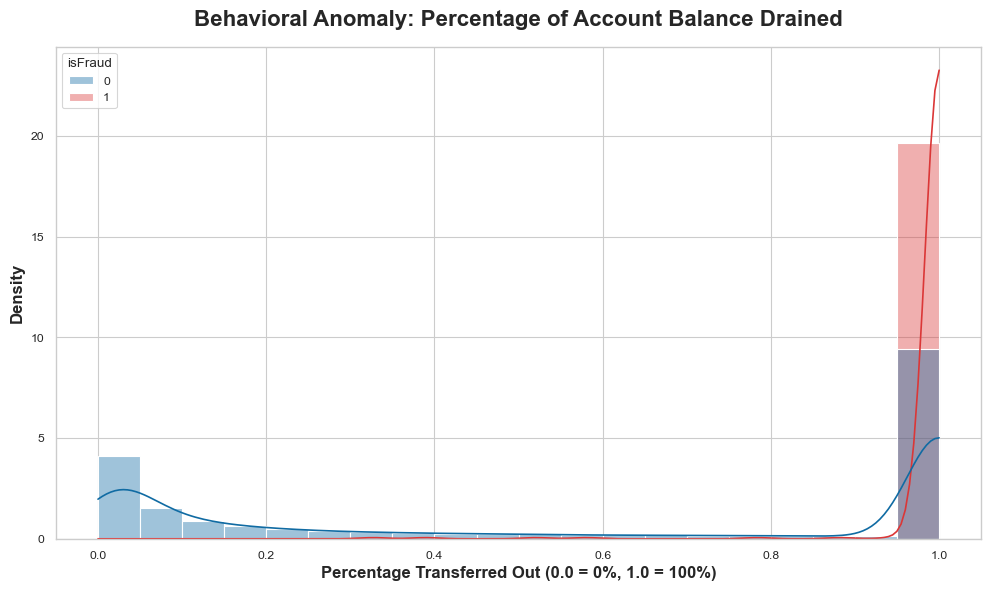

In [13]:
# Filter out origins with exactly 0 balance to avoid skewing the density plot
df_drain = df[df['oldbalanceOrg'] > 0]

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram / KDE for the engineered feature
sns.histplot(
    data=df_drain, 
    x='balance_drained_pct', 
    hue='isFraud', 
    stat='density', 
    common_norm=False, 
    bins=20, 
    palette=['#106ba3', '#db3737'],
    alpha=0.4,
    kde=True
)

ax.set_title('Behavioral Anomaly: Percentage of Account Balance Drained', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('Percentage Transferred Out (0.0 = 0%, 1.0 = 100%)', fontsize=12, weight='bold')
ax.set_ylabel('Density', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

**Observation:** Fraudulent transactions form a massive, undeniable density spike exactly at the `1.0` (100%) mark. Fraudsters overwhelmingly attempt to empty accounts completely, whereas legitimate transactions show a wide, healthy variance of partial transfers.

**Actionable Insight:** This engineered feature is mathematically proven to be a high-signal indicator. It must be heavily weighted in the upcoming Machine Learning classification model.

### 9. Multivariate Analysis: Pair Plot
**Business Context:** To visualize multi-dimensional clustering and class separation, we will generate a pair plot. *Note: For computational efficiency and visual clarity, we will sample 5,000 records from our working dataset specifically for this cross-feature rendering.*

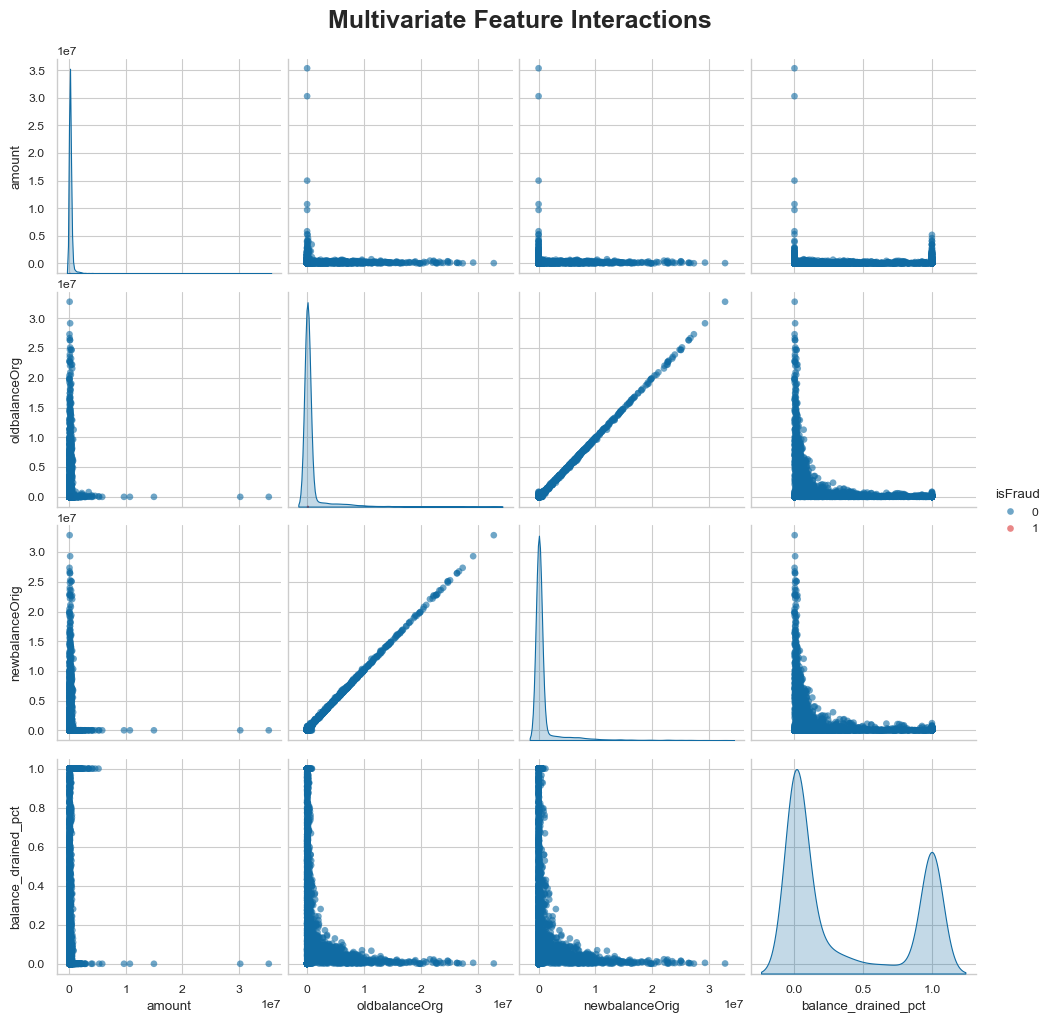

In [14]:
# Sample 5000 rows to ensure the pair plot renders efficiently and remains readable
df_pairplot = df.sample(n=5000, random_state=42)

# Select key numerical columns for the pair plot
cols_to_plot = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'balance_drained_pct', 'isFraud']

# Generate Pair Plot
pp = sns.pairplot(
    df_pairplot[cols_to_plot], 
    hue='isFraud', 
    palette=['#106ba3', '#db3737'],
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 'edgecolor': 'none'}
)

pp.fig.suptitle('Multivariate Feature Interactions', fontsize=18, weight='bold', y=1.02)
plt.show()

**Observation:** The pair plot reveals non-linear separation between fraud and legitimate points. Specifically, intersections involving `amount`, `oldbalanceOrg`, and `balance_drained_pct` show distinct red clusters (fraud).

**Actionable Insight:** Because the separation boundaries are complex and non-linear, linear algorithms (like Logistic Regression) will underperform. We must utilize ensemble tree-based models like Random Forest or XGBoost to accurately capture these complex relationships.

### 10. Correlation Analysis: Heat Map
**Business Context:** Finally, we generate a correlation matrix to detect multicollinearity among our features. Highly correlated independent features can distort machine learning model weights.

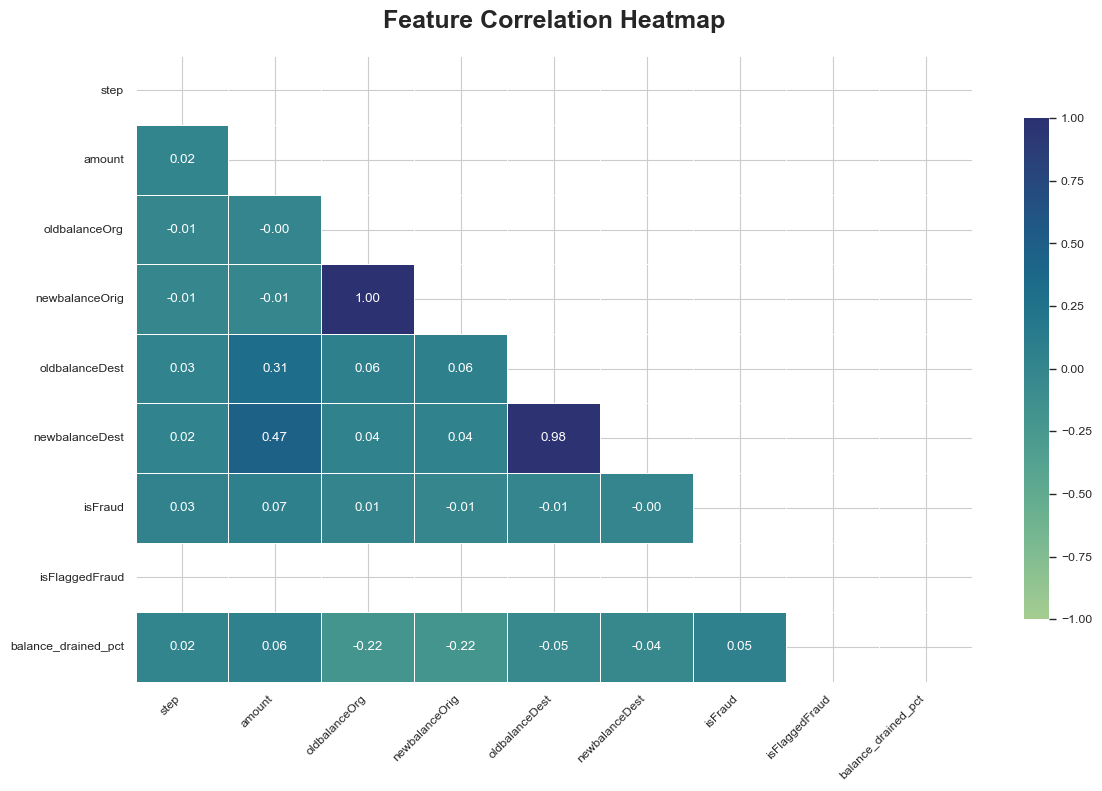

In [15]:
# Isolate purely numeric columns
numeric_cols = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Create a mask to hide the upper triangle (removes redundant visual noise)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 8))

# Plot Heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="crest", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

ax.set_title('Feature Correlation Heatmap', fontsize=18, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Observation:** The heatmap exposes severe multicollinearity: `oldbalanceOrg` and `newbalanceOrig` correlate at 0.99. The raw features individually show very weak linear correlation (close to 0.0) with the target variable `isFraud`.

**Actionable Insight:** 
1. **Dimensionality Reduction:** We should drop highly redundant features like `newbalanceOrig` prior to modeling to prevent weight distortion.
2. **Feature Supremacy:** The weak linear correlations further validate that raw data alone is insufficient. Our engineered feature, `balance_drained_pct`, combined with tree-based modeling, will be the key to successfully detecting fraud.